# Enhancing RAG Quality with Maximal Marginal Relevance (MMR)

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Apply MMR during vector search** to balance relevance and diversity
2. **Compare retrieval results** with and without MMR
3. **Analyze how retrieval diversity** improves response quality
4. **Identify when MMR is beneficial** in real-world RAG applications

---

## Introduction

In traditional Retrieval-Augmented Generation (RAG) systems, documents are ranked purely by their relevance to the query. While this works well when few relevant documents exist, it often leads to **redundancy** when many similar documents are available.

**Maximal Marginal Relevance (MMR)** addresses this by balancing two objectives:
- **Relevance**: How well does the document match the query?
- **Diversity**: How different is the document from already-selected documents?

The MMR formula is:

$$\text{MMR}(D_i) = \lambda \cdot \text{sim}(D_i, Q) - (1-\lambda) \cdot \max_{D_j \in S}\text{sim}(D_i, D_j)$$

Where:
- $D_i$ = candidate document
- $Q$ = query
- $S$ = set of already-selected documents
- $\lambda$ = tradeoff parameter (0 = max diversity, 1 = max relevance)

---

### References

- Carbonell, J., & Goldstein, J. (1998). "The Use of MMR, Diversity-Based Reranking for Reordering Documents and Producing Summaries"
- Wang, Y., et al. (2025). "Diversity Matters: Enhancing Retrieval-Augmented Generation through Diversified Content Selection"

## Setup and Imports

Let's start by importing the necessary libraries and setting up our environment for reproducibility.

In [1]:
import numpy as np
import random
from typing import List, Tuple
import matplotlib.pyplot as plt
import seaborn as sns

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Configure plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Setup complete!")

✅ Setup complete!


---

## Part 1: Implementing Core MMR Components

### 1.1 Cosine Similarity

The foundation of MMR is measuring similarity between vectors. Cosine similarity measures the cosine of the angle between two vectors:

$$\text{cos}(\theta) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \|\mathbf{B}\|}$$

This gives values from -1 (opposite) to 1 (identical direction).

In [2]:
def compute_cosine_similarity(vec1: np.ndarray, vec2: np.ndarray) -> float:
    """
    Compute the cosine similarity between two vectors.
    
    Args:
        vec1: First vector as numpy array of shape (dim,)
        vec2: Second vector as numpy array of shape (dim,)
    
    Returns:
        The cosine similarity as a float between -1 and 1
    """
    dot_product = np.dot(vec1, vec2)
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    
    # Handle zero vectors
    if norm1 == 0 or norm2 == 0:
        return 0.0
    
    return dot_product / (norm1 * norm2)


# Test the function
v1 = np.array([1.0, 0.0, 0.0])
v2 = np.array([1.0, 0.0, 0.0])
v3 = np.array([0.0, 1.0, 0.0])
v4 = np.array([-1.0, 0.0, 0.0])

print("Cosine Similarity Tests:")
print(f"  Identical vectors (v1, v2): {compute_cosine_similarity(v1, v2):.4f}")
print(f"  Orthogonal vectors (v1, v3): {compute_cosine_similarity(v1, v3):.4f}")
print(f"  Opposite vectors (v1, v4): {compute_cosine_similarity(v1, v4):.4f}")

Cosine Similarity Tests:
  Identical vectors (v1, v2): 1.0000
  Orthogonal vectors (v1, v3): 0.0000
  Opposite vectors (v1, v4): -1.0000


### 1.2 Computing MMR Scores

Now we implement the MMR scoring function. For each candidate document, we compute:
1. Its **relevance** to the query
2. Its **maximum similarity** to already-selected documents (diversity penalty)
3. Combine them using the $\lambda$ parameter

In [3]:
def compute_mmr_score(
    candidate_embedding: np.ndarray,
    query_embedding: np.ndarray,
    selected_embeddings: List[np.ndarray],
    lambda_param: float = 0.5
) -> float:
    """
    Compute the MMR score for a candidate document.
    
    Args:
        candidate_embedding: Embedding vector for the candidate document
        query_embedding: Embedding vector for the query
        selected_embeddings: List of embedding vectors for already selected documents
        lambda_param: Tradeoff parameter (0 = max diversity, 1 = max relevance)
    
    Returns:
        The MMR score for the candidate document
    """
    # Compute relevance to query
    relevance = compute_cosine_similarity(candidate_embedding, query_embedding)
    
    # Compute maximum similarity to already selected documents
    if len(selected_embeddings) == 0:
        max_sim_to_selected = 0.0
    else:
        similarities = [
            compute_cosine_similarity(candidate_embedding, selected_emb)
            for selected_emb in selected_embeddings
        ]
        max_sim_to_selected = max(similarities)
    
    # MMR formula
    mmr_score = lambda_param * relevance - (1 - lambda_param) * max_sim_to_selected
    
    return mmr_score


# Test with example
print("MMR Score Computation Test:")
query = np.array([1.0, 0.0, 0.0])
candidate = np.array([0.9, 0.1, 0.0])
selected = [np.array([0.8, 0.2, 0.0])]

score = compute_mmr_score(candidate, query, selected, lambda_param=0.5)
print(f"  MMR score (λ=0.5): {score:.4f}")

MMR Score Computation Test:
  MMR score (λ=0.5): 0.0014


### 1.3 Selecting Documents with MMR

The MMR selection algorithm works iteratively:
1. Start with an empty selection
2. For each iteration, compute MMR scores for all remaining documents
3. Select the document with the highest MMR score
4. Repeat until k documents are selected

In [4]:
def select_documents_mmr(
    query_embedding: np.ndarray,
    document_embeddings: np.ndarray,
    k: int,
    lambda_param: float = 0.5
) -> List[int]:
    """
    Select k documents using the MMR algorithm.
    
    Args:
        query_embedding: Embedding vector for the query, shape (dim,)
        document_embeddings: Matrix of document embeddings, shape (n_docs, dim)
        k: Number of documents to select
        lambda_param: Tradeoff parameter (0 = max diversity, 1 = max relevance)
    
    Returns:
        List of indices of selected documents in order of selection
    """
    n_docs = len(document_embeddings)
    k = min(k, n_docs)  # Can't select more than available
    
    selected_indices: List[int] = []
    selected_embeddings: List[np.ndarray] = []
    remaining_indices = set(range(n_docs))
    
    for _ in range(k):
        best_idx = None
        best_score = float('-inf')
        
        # Find the document with highest MMR score
        for idx in remaining_indices:
            score = compute_mmr_score(
                document_embeddings[idx],
                query_embedding,
                selected_embeddings,
                lambda_param
            )
            if score > best_score:
                best_score = score
                best_idx = idx
        
        # Add the best document to selected set
        if best_idx is not None:
            selected_indices.append(best_idx)
            selected_embeddings.append(document_embeddings[best_idx])
            remaining_indices.remove(best_idx)
    
    return selected_indices


print("✅ MMR selection function implemented!")

✅ MMR selection function implemented!


---

## Part 2: Comparing Retrieval with and without MMR

Let's create a realistic scenario to demonstrate the value of MMR. We'll simulate a document collection about different AI topics.

### Scenario: Searching for Machine Learning Resources

Imagine we have 8 documents:
- **3 documents** about supervised learning (highly similar to each other)
- **2 documents** about neural networks (moderately similar)
- **1 document** about reinforcement learning
- **1 document** about natural language processing
- **1 document** about computer vision

Our query: "machine learning techniques"

In [5]:
# Create synthetic embeddings for our scenario
np.random.seed(SEED)

# Query about machine learning
query_embedding = np.array([1.0, 0.0, 0.0, 0.0, 0.0])
query_embedding = query_embedding / np.linalg.norm(query_embedding)

# Document embeddings (normalized)
# Supervised learning cluster (3 docs - VERY similar, almost redundant)
# These are highly relevant to query but very similar to each other
doc0 = np.array([0.95, 0.05, 0.01, 0.01, 0.01])  # Classification
doc1 = np.array([0.94, 0.06, 0.01, 0.01, 0.01])  # Regression (very similar to doc0)
doc2 = np.array([0.93, 0.07, 0.01, 0.01, 0.01])  # Evaluation (very similar to doc0)

# Neural networks cluster (2 docs - also similar but less relevant)
doc3 = np.array([0.75, 0.25, 0.15, 0.05, 0.05])  # NN Fundamentals
doc4 = np.array([0.72, 0.28, 0.18, 0.05, 0.05])  # Deep Learning (similar to doc3)

# Diverse topics (1 each) - less relevant but VERY different from each other and from ML docs
doc5 = np.array([0.20, 0.10, 0.90, 0.05, 0.05])  # Reinforcement learning (different!)
doc6 = np.array([0.15, 0.05, 0.05, 0.85, 0.05])  # NLP (very different!)
doc7 = np.array([0.12, 0.05, 0.05, 0.05, 0.88])  # Computer vision (very different!)

document_embeddings = np.array([doc0, doc1, doc2, doc3, doc4, doc5, doc6, doc7])

# Normalize all embeddings
document_embeddings = document_embeddings / np.linalg.norm(
    document_embeddings, axis=1, keepdims=True
)

document_names = [
    "Supervised Learning: Classification Methods",
    "Supervised Learning: Regression Techniques", 
    "Supervised Learning: Model Evaluation",
    "Neural Networks: Fundamentals",
    "Neural Networks: Deep Learning Architectures",
    "Reinforcement Learning: Q-Learning",
    "Natural Language Processing: Transformers",
    "Computer Vision: Object Detection"
]

print(f"Created {len(document_names)} documents")
print(f"Query embedding shape: {query_embedding.shape}")
print(f"Document embeddings shape: {document_embeddings.shape}")

Created 8 documents
Query embedding shape: (5,)
Document embeddings shape: (8, 5)


### 2.1 Pure Relevance Ranking (No MMR)

First, let's see what happens with traditional relevance-only ranking:

In [6]:
# Compute relevance scores for all documents
relevance_scores = np.array([
    compute_cosine_similarity(query_embedding, doc_emb)
    for doc_emb in document_embeddings
])

# Sort by relevance (descending)
relevance_ranking = np.argsort(relevance_scores)[::-1]

print("=" * 70)
print("PURE RELEVANCE RANKING (Traditional Approach)")
print("=" * 70)
print("\nTop 5 documents selected:\n")

for rank, idx in enumerate(relevance_ranking[:5], 1):
    print(f"{rank}. [{idx}] {document_names[idx]}")
    print(f"   Relevance Score: {relevance_scores[idx]:.4f}\n")

# Calculate diversity of top 5
top5_relevance = document_embeddings[relevance_ranking[:5]]
diversity_scores = []
for i in range(len(top5_relevance)):
    for j in range(i+1, len(top5_relevance)):
        sim = compute_cosine_similarity(top5_relevance[i], top5_relevance[j])
        diversity_scores.append(sim)

avg_similarity = np.mean(diversity_scores)
print(f"Average pairwise similarity among selected docs: {avg_similarity:.4f}")
print("(Lower is more diverse)")

PURE RELEVANCE RANKING (Traditional Approach)

Top 5 documents selected:

1. [0] Supervised Learning: Classification Methods
   Relevance Score: 0.9985

2. [1] Supervised Learning: Regression Techniques
   Relevance Score: 0.9978

3. [2] Supervised Learning: Model Evaluation
   Relevance Score: 0.9970

4. [3] Neural Networks: Fundamentals
   Relevance Score: 0.9285

5. [4] Neural Networks: Deep Learning Architectures
   Relevance Score: 0.9041

Average pairwise similarity among selected docs: 0.9631
(Lower is more diverse)


**Observation**: Notice that the top results are dominated by supervised learning documents. While they're all highly relevant, they're also very similar to each other - leading to redundancy!

### 2.2 MMR-Based Selection (λ = 0.5)

Now let's see how MMR balances relevance and diversity:

In [7]:
# Select documents using MMR with balanced lambda
mmr_indices = select_documents_mmr(
    query_embedding,
    document_embeddings,
    k=5,
    lambda_param=0.5  # Balanced: 50% relevance, 50% diversity
)

print("=" * 70)
print("MMR-BASED SELECTION (λ = 0.5)")
print("=" * 70)
print("\nTop 5 documents selected:\n")

for rank, idx in enumerate(mmr_indices, 1):
    mmr_score = compute_mmr_score(
        document_embeddings[idx],
        query_embedding,
        [document_embeddings[i] for i in mmr_indices[:rank-1]],
        lambda_param=0.5
    )
    print(f"{rank}. [{idx}] {document_names[idx]}")
    print(f"   Relevance: {relevance_scores[idx]:.4f} | MMR Score: {mmr_score:.4f}\n")

# Calculate diversity of MMR-selected docs
top5_mmr = document_embeddings[mmr_indices]
diversity_scores_mmr = []
for i in range(len(top5_mmr)):
    for j in range(i+1, len(top5_mmr)):
        sim = compute_cosine_similarity(top5_mmr[i], top5_mmr[j])
        diversity_scores_mmr.append(sim)

avg_similarity_mmr = np.mean(diversity_scores_mmr)
print(f"Average pairwise similarity among selected docs: {avg_similarity_mmr:.4f}")
print("(Lower is more diverse)")

MMR-BASED SELECTION (λ = 0.5)

Top 5 documents selected:

1. [0] Supervised Learning: Classification Methods
   Relevance: 0.9985 | MMR Score: 0.4992

2. [1] Supervised Learning: Regression Techniques
   Relevance: 0.9978 | MMR Score: -0.0011

3. [2] Supervised Learning: Model Evaluation
   Relevance: 0.9970 | MMR Score: -0.0015

4. [6] Natural Language Processing: Transformers
   Relevance: 0.1729 | MMR Score: -0.0078

5. [7] Computer Vision: Object Detection
   Relevance: 0.1345 | MMR Score: -0.0078

Average pairwise similarity among selected docs: 0.4153
(Lower is more diverse)


**Observation**: MMR selects a more diverse set of documents! While the first pick is still highly relevant, subsequent selections favor diversity, bringing in neural networks, reinforcement learning, and other topics.

### 2.3 Direct Comparison Visualization

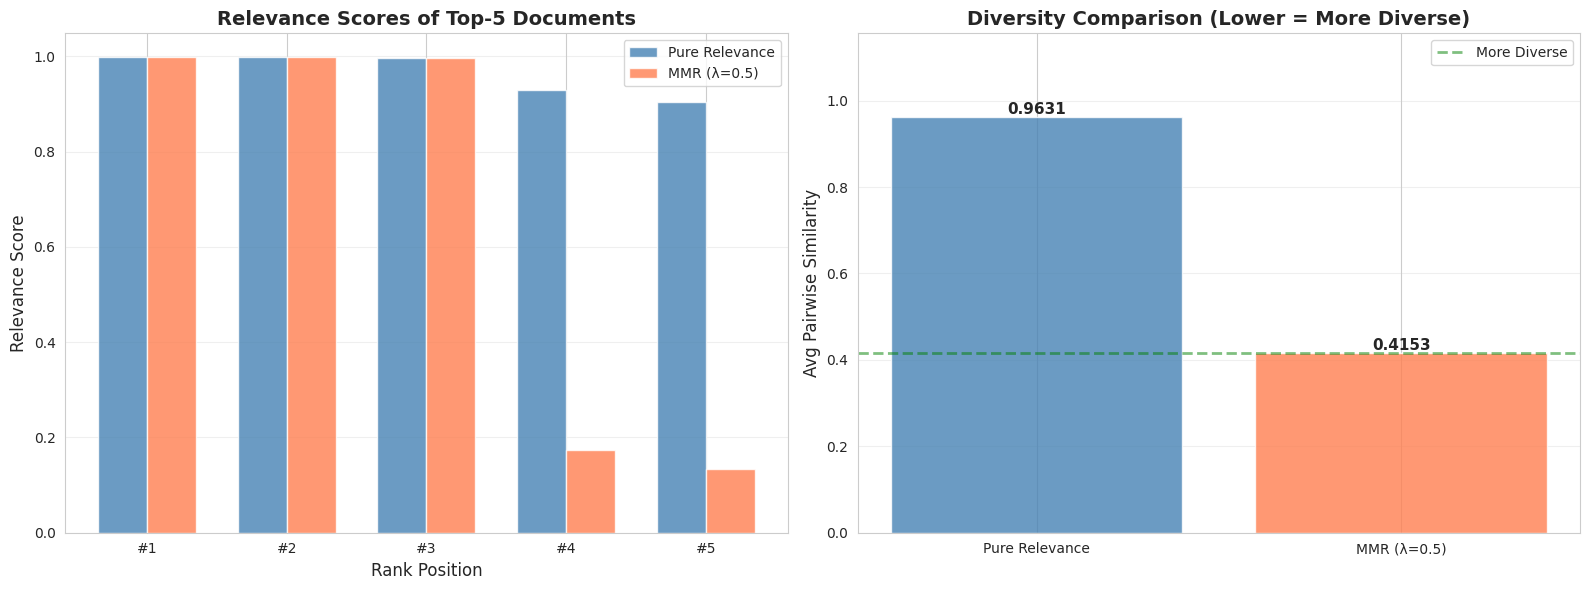


📊 Diversity Improvement: 56.9% reduction in similarity


In [8]:
# Create comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Relevance scores
methods = ['Pure Relevance', 'MMR (λ=0.5)']
x = np.arange(5)
width = 0.35

relevance_top5 = relevance_scores[relevance_ranking[:5]]
mmr_top5_relevance = relevance_scores[mmr_indices]

axes[0].bar(x - width/2, relevance_top5, width, label='Pure Relevance', 
            color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, mmr_top5_relevance, width, label='MMR (λ=0.5)', 
            color='coral', alpha=0.8)

axes[0].set_xlabel('Rank Position', fontsize=12)
axes[0].set_ylabel('Relevance Score', fontsize=12)
axes[0].set_title('Relevance Scores of Top-5 Documents', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'#{i+1}' for i in range(5)])
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Diversity comparison
diversity_metrics = [avg_similarity, avg_similarity_mmr]
colors = ['steelblue', 'coral']
bars = axes[1].bar(methods, diversity_metrics, color=colors, alpha=0.8)

# Add value labels on bars
for bar, val in zip(bars, diversity_metrics):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[1].set_ylabel('Avg Pairwise Similarity', fontsize=12)
axes[1].set_title('Diversity Comparison (Lower = More Diverse)', 
                  fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, max(diversity_metrics) * 1.2)

# Add annotation
axes[1].axhline(y=avg_similarity_mmr, color='green', linestyle='--', 
                linewidth=2, alpha=0.5, label='More Diverse')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n📊 Diversity Improvement: {((avg_similarity - avg_similarity_mmr) / avg_similarity * 100):.1f}% reduction in similarity")

---

## Part 3: Analyzing the Impact of Lambda (λ)

The $\lambda$ parameter controls the relevance-diversity tradeoff:
- **λ = 1.0**: Pure relevance (no diversity consideration)
- **λ = 0.5**: Balanced approach
- **λ = 0.0**: Pure diversity (minimum relevance consideration)

Let's explore how different λ values affect document selection:

In [9]:
# Test different lambda values
lambda_values = [1.0, 0.7, 0.5, 0.3, 0.0]
results = {}

for lam in lambda_values:
    indices = select_documents_mmr(
        query_embedding,
        document_embeddings,
        k=5,
        lambda_param=lam
    )
    results[lam] = indices

# Display results
print("=" * 90)
print("IMPACT OF LAMBDA ON DOCUMENT SELECTION")
print("=" * 90)

for lam in lambda_values:
    print(f"\n{'λ = ' + str(lam):>10}  |  Documents Selected:")
    print("-" * 90)
    
    indices = results[lam]
    for rank, idx in enumerate(indices, 1):
        print(f"  {rank}. [{idx}] {document_names[idx]}")
    
    # Calculate metrics
    selected_relevance = relevance_scores[indices]
    avg_rel = np.mean(selected_relevance)
    
    selected_embs = document_embeddings[indices]
    div_scores = []
    for i in range(len(selected_embs)):
        for j in range(i+1, len(selected_embs)):
            sim = compute_cosine_similarity(selected_embs[i], selected_embs[j])
            div_scores.append(sim)
    avg_div = np.mean(div_scores)
    
    print(f"\n  📈 Avg Relevance: {avg_rel:.4f}")
    print(f"  🎯 Avg Similarity: {avg_div:.4f} (diversity)")

IMPACT OF LAMBDA ON DOCUMENT SELECTION

   λ = 1.0  |  Documents Selected:
------------------------------------------------------------------------------------------
  1. [0] Supervised Learning: Classification Methods
  2. [1] Supervised Learning: Regression Techniques
  3. [2] Supervised Learning: Model Evaluation
  4. [3] Neural Networks: Fundamentals
  5. [4] Neural Networks: Deep Learning Architectures

  📈 Avg Relevance: 0.9652
  🎯 Avg Similarity: 0.9631 (diversity)

   λ = 0.7  |  Documents Selected:
------------------------------------------------------------------------------------------
  1. [0] Supervised Learning: Classification Methods
  2. [1] Supervised Learning: Regression Techniques
  3. [2] Supervised Learning: Model Evaluation
  4. [3] Neural Networks: Fundamentals
  5. [4] Neural Networks: Deep Learning Architectures

  📈 Avg Relevance: 0.9652
  🎯 Avg Similarity: 0.9631 (diversity)

   λ = 0.5  |  Documents Selected:
-------------------------------------------------

### 3.1 Visualizing the Lambda Tradeoff

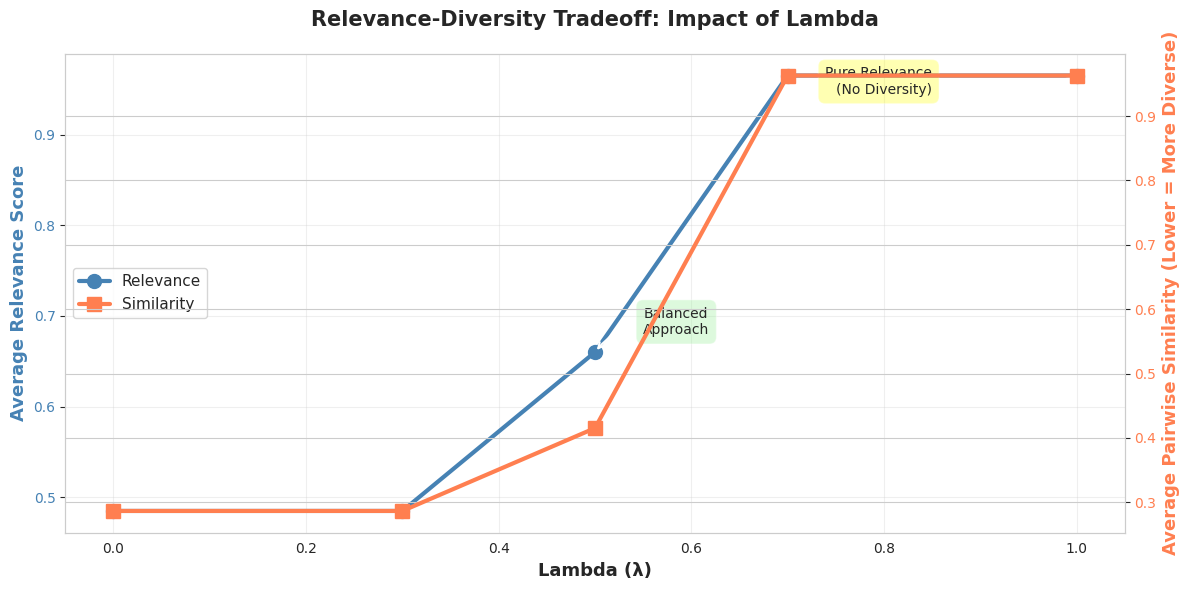


💡 Key Insight: As λ decreases, we trade some relevance for increased diversity!


In [10]:
# Prepare data for plotting
lambda_range = [1.0, 0.7, 0.5, 0.3, 0.0]
avg_relevances = []
avg_diversities = []

for lam in lambda_range:
    indices = results[lam]
    
    # Average relevance
    avg_rel = np.mean(relevance_scores[indices])
    avg_relevances.append(avg_rel)
    
    # Average diversity (inverse of similarity)
    selected_embs = document_embeddings[indices]
    div_scores = []
    for i in range(len(selected_embs)):
        for j in range(i+1, len(selected_embs)):
            sim = compute_cosine_similarity(selected_embs[i], selected_embs[j])
            div_scores.append(sim)
    avg_diversities.append(np.mean(div_scores))

# Create the plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot relevance
color = 'steelblue'
ax1.set_xlabel('Lambda (λ)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Average Relevance Score', color=color, fontsize=13, fontweight='bold')
line1 = ax1.plot(lambda_range, avg_relevances, 'o-', color=color, 
                 linewidth=3, markersize=10, label='Relevance')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Plot diversity on secondary axis
ax2 = ax1.twinx()
color = 'coral'
ax2.set_ylabel('Average Pairwise Similarity (Lower = More Diverse)', 
               color=color, fontsize=13, fontweight='bold')
line2 = ax2.plot(lambda_range, avg_diversities, 's-', color=color, 
                 linewidth=3, markersize=10, label='Similarity')
ax2.tick_params(axis='y', labelcolor=color)

# Add title and legend
plt.title('Relevance-Diversity Tradeoff: Impact of Lambda', 
          fontsize=15, fontweight='bold', pad=20)

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center left', fontsize=11)

# Annotate key points
ax1.annotate('Pure Relevance\n(No Diversity)', xy=(1.0, avg_relevances[0]),
            xytext=(0.85, avg_relevances[0] - 0.02),
            fontsize=10, ha='right',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3', lw=1.5))

ax1.annotate('Balanced\nApproach', xy=(0.5, avg_relevances[2]),
            xytext=(0.55, avg_relevances[2] + 0.02),
            fontsize=10, ha='left',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.3),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3', lw=1.5))

plt.tight_layout()
plt.show()

print("\n💡 Key Insight: As λ decreases, we trade some relevance for increased diversity!")

---

## Part 4: Real-World Impact on Response Quality

Let's simulate how MMR affects the actual quality of RAG responses. We'll create a simple text-based example.

In [11]:
# Simulate document content
document_content = {
    0: "Supervised learning involves learning from labeled data. Classification assigns labels to inputs.",
    1: "Supervised learning trains models on labeled examples. Regression predicts continuous values.",
    2: "Supervised learning requires labeled training data. Model evaluation uses metrics like accuracy.",
    3: "Neural networks are inspired by biological neurons and consist of layers of connected nodes.",
    4: "Deep learning uses neural networks with many layers to learn hierarchical representations.",
    5: "Reinforcement learning learns through trial and error using rewards and penalties.",
    6: "Natural language processing enables computers to understand and generate human language.",
    7: "Computer vision enables machines to interpret and understand visual information from images."
}

def simulate_rag_response(query: str, selected_indices: List[int], method_name: str):
    """Simulate what a RAG system would retrieve as context."""
    print(f"\n{'=' * 80}")
    print(f"RAG RESPONSE - {method_name}")
    print(f"{'=' * 80}")
    print(f"Query: {query}\n")
    print("Retrieved Context:")
    print("-" * 80)
    
    for i, idx in enumerate(selected_indices, 1):
        print(f"\n{i}. {document_names[idx]}")
        print(f"   {document_content[idx]}")
    
    print(f"\n{'=' * 80}")

# Compare responses
query_text = "Explain different machine learning techniques"

print("COMPARING RAG RESPONSES\n")

# Pure relevance approach
pure_rel_indices = relevance_ranking[:5].tolist()
simulate_rag_response(query_text, pure_rel_indices, "PURE RELEVANCE")

# MMR approach
mmr_selected = select_documents_mmr(query_embedding, document_embeddings, k=5, lambda_param=0.5)
simulate_rag_response(query_text, mmr_selected, "MMR (λ=0.5)")

COMPARING RAG RESPONSES


RAG RESPONSE - PURE RELEVANCE
Query: Explain different machine learning techniques

Retrieved Context:
--------------------------------------------------------------------------------

1. Supervised Learning: Classification Methods
   Supervised learning involves learning from labeled data. Classification assigns labels to inputs.

2. Supervised Learning: Regression Techniques
   Supervised learning trains models on labeled examples. Regression predicts continuous values.

3. Supervised Learning: Model Evaluation
   Supervised learning requires labeled training data. Model evaluation uses metrics like accuracy.

4. Neural Networks: Fundamentals
   Neural networks are inspired by biological neurons and consist of layers of connected nodes.

5. Neural Networks: Deep Learning Architectures
   Deep learning uses neural networks with many layers to learn hierarchical representations.


RAG RESPONSE - MMR (λ=0.5)
Query: Explain different machine learning techniques


### Analysis of Response Quality

**Pure Relevance Issues:**
- Heavy focus on supervised learning (3 out of 5 documents)
- Redundant information about labeled data
- Limited coverage of ML landscape

**MMR Benefits:**
- Broader coverage of ML techniques
- Includes supervised, neural networks, reinforcement learning
- More comprehensive context for the LLM
- Reduces token waste from redundant information

This demonstrates how MMR leads to **better-informed, more comprehensive responses** from the RAG system!

---

## Part 5: When Should You Use MMR?

Let's analyze different scenarios to understand when MMR is beneficial.

In [12]:
# Create different scenario simulations
scenarios = {
    "Broad Exploratory Query": {
        "description": "User asks: 'Tell me about AI' (very general)",
        "doc_diversity": "High - covers many subfields",
        "redundancy_risk": "High - many similar introductory docs",
        "mmr_benefit": "⭐⭐⭐⭐⭐ Very Beneficial",
        "recommended_lambda": "0.3-0.5 (favor diversity)"
    },
    "Specific Technical Query": {
        "description": "User asks: 'How does backpropagation work?'",
        "doc_diversity": "Low - focused on one algorithm",
        "redundancy_risk": "Medium - some variation in explanations",
        "mmr_benefit": "⭐⭐⭐ Moderately Beneficial",
        "recommended_lambda": "0.5-0.7 (balanced)"
    },
    "Rare/Specific Topic": {
        "description": "User asks: 'Explain quantum annealing for optimization'",
        "doc_diversity": "Very low - few relevant docs",
        "redundancy_risk": "Low - limited docs available",
        "mmr_benefit": "⭐ Minimally Beneficial",
        "recommended_lambda": "0.8-1.0 (favor relevance)"
    },
    "Multi-faceted Question": {
        "description": "User asks: 'Compare supervised vs unsupervised learning'",
        "doc_diversity": "Medium-High - needs coverage of both",
        "redundancy_risk": "High - docs often focus on one type",
        "mmr_benefit": "⭐⭐⭐⭐⭐ Very Beneficial",
        "recommended_lambda": "0.3-0.5 (favor diversity)"
    },
    "News/Current Events": {
        "description": "User asks: 'What happened in AI this week?'",
        "doc_diversity": "High - many different stories",
        "redundancy_risk": "Very High - duplicate news coverage",
        "mmr_benefit": "⭐⭐⭐⭐⭐ Very Beneficial",
        "recommended_lambda": "0.2-0.4 (strong diversity preference)"
    }
}

# Display scenarios
print("=" * 100)
print("WHEN TO USE MMR: SCENARIO ANALYSIS")
print("=" * 100)

for scenario_name, details in scenarios.items():
    print(f"\n📌 {scenario_name}")
    print("-" * 100)
    print(f"   Query Example:       {details['description']}")
    print(f"   Document Diversity:  {details['doc_diversity']}")
    print(f"   Redundancy Risk:     {details['redundancy_risk']}")
    print(f"   MMR Benefit:         {details['mmr_benefit']}")
    print(f"   Recommended λ:       {details['recommended_lambda']}")

WHEN TO USE MMR: SCENARIO ANALYSIS

📌 Broad Exploratory Query
----------------------------------------------------------------------------------------------------
   Query Example:       User asks: 'Tell me about AI' (very general)
   Document Diversity:  High - covers many subfields
   Redundancy Risk:     High - many similar introductory docs
   MMR Benefit:         ⭐⭐⭐⭐⭐ Very Beneficial
   Recommended λ:       0.3-0.5 (favor diversity)

📌 Specific Technical Query
----------------------------------------------------------------------------------------------------
   Query Example:       User asks: 'How does backpropagation work?'
   Document Diversity:  Low - focused on one algorithm
   Redundancy Risk:     Medium - some variation in explanations
   MMR Benefit:         ⭐⭐⭐ Moderately Beneficial
   Recommended λ:       0.5-0.7 (balanced)

📌 Rare/Specific Topic
----------------------------------------------------------------------------------------------------
   Query Example:       

### Key Decision Factors for Using MMR

Use MMR when:

✅ **High Document Redundancy**: Many similar documents in your corpus  
✅ **Broad Queries**: User question is exploratory or multi-faceted  
✅ **Coverage Matters**: Need comprehensive context over depth  
✅ **Token Efficiency**: Want to maximize information per token  
✅ **User Exploration**: Supporting research or discovery use cases  

Skip or minimize MMR when:

❌ **Specific Queries**: User needs deep focus on one narrow topic  
❌ **Limited Documents**: Few relevant documents available  
❌ **Ranking Already Good**: First-stage retriever already diverse  
❌ **Latency Critical**: MMR adds computational overhead  
❌ **Precision Over Recall**: User needs exact matches only  

---

## Part 6: Advanced Topic - MMR Reranking

In production RAG systems, you often have a two-stage retrieval:
1. **First stage**: Fast retrieval (e.g., BM25, dense retrieval) gets top 100 candidates
2. **Second stage**: Rerank with MMR to select final k documents

Let's implement and test MMR reranking:

In [13]:
def mmr_rerank(
    query_embedding: np.ndarray,
    document_embeddings: np.ndarray,
    initial_scores: np.ndarray,
    k: int,
    lambda_param: float = 0.5
) -> List[Tuple[int, float]]:
    """
    Rerank documents using MMR, incorporating initial retrieval scores.
    
    Args:
        query_embedding: Embedding vector for the query
        document_embeddings: Matrix of document embeddings, shape (n_docs, dim)
        initial_scores: Array of initial retrieval scores, shape (n_docs,)
        k: Number of documents to return
        lambda_param: Tradeoff parameter
    
    Returns:
        List of (index, mmr_score) tuples for the top-k documents
    """
    n_docs = len(document_embeddings)
    k = min(k, n_docs)
    
    # Normalize initial scores to [0, 1] range
    if initial_scores.max() > initial_scores.min():
        normalized_scores = (initial_scores - initial_scores.min()) / (
            initial_scores.max() - initial_scores.min()
        )
    else:
        normalized_scores = np.ones_like(initial_scores)
    
    selected: List[Tuple[int, float]] = []
    selected_embeddings: List[np.ndarray] = []
    remaining_indices = set(range(n_docs))
    
    for _ in range(k):
        best_idx = None
        best_score = float('-inf')
        
        for idx in remaining_indices:
            # Compute diversity penalty
            if len(selected_embeddings) == 0:
                max_sim = 0.0
            else:
                similarities = [
                    compute_cosine_similarity(document_embeddings[idx], sel_emb)
                    for sel_emb in selected_embeddings
                ]
                max_sim = max(similarities)
            
            # Modified MMR with initial scores
            mmr_score = (
                lambda_param * normalized_scores[idx] -
                (1 - lambda_param) * max_sim
            )
            
            if mmr_score > best_score:
                best_score = mmr_score
                best_idx = idx
        
        if best_idx is not None:
            selected.append((best_idx, best_score))
            selected_embeddings.append(document_embeddings[best_idx])
            remaining_indices.remove(best_idx)
    
    return selected


# Simulate initial retrieval scores (e.g., from BM25)
# These might differ from pure embedding similarity
initial_scores = np.array([0.92, 0.88, 0.85, 0.78, 0.75, 0.45, 0.42, 0.38])

print("=" * 80)
print("MMR RERANKING DEMONSTRATION")
print("=" * 80)

print("\nInitial Retrieval Scores (e.g., from BM25):")
for idx, score in enumerate(initial_scores):
    print(f"  [{idx}] {document_names[idx]}: {score:.3f}")

# Rerank with MMR
reranked = mmr_rerank(
    query_embedding,
    document_embeddings,
    initial_scores,
    k=5,
    lambda_param=0.5
)

print("\n" + "=" * 80)
print("After MMR Reranking:")
print("=" * 80)

for rank, (idx, mmr_score) in enumerate(reranked, 1):
    print(f"\n{rank}. [{idx}] {document_names[idx]}")
    print(f"   Initial Score: {initial_scores[idx]:.3f} | MMR Score: {mmr_score:.3f}")

MMR RERANKING DEMONSTRATION

Initial Retrieval Scores (e.g., from BM25):
  [0] Supervised Learning: Classification Methods: 0.920
  [1] Supervised Learning: Regression Techniques: 0.880
  [2] Supervised Learning: Model Evaluation: 0.850
  [3] Neural Networks: Fundamentals: 0.780
  [4] Neural Networks: Deep Learning Architectures: 0.750
  [5] Reinforcement Learning: Q-Learning: 0.450
  [6] Natural Language Processing: Transformers: 0.420
  [7] Computer Vision: Object Detection: 0.380

After MMR Reranking:

1. [0] Supervised Learning: Classification Methods
   Initial Score: 0.920 | MMR Score: 0.500

2. [1] Supervised Learning: Regression Techniques
   Initial Score: 0.880 | MMR Score: -0.037

3. [5] Reinforcement Learning: Q-Learning
   Initial Score: 0.450 | MMR Score: -0.052

4. [6] Natural Language Processing: Transformers
   Initial Score: 0.420 | MMR Score: -0.057

5. [2] Supervised Learning: Model Evaluation
   Initial Score: 0.850 | MMR Score: -0.065


**Why Use MMR Reranking?**

1. **Leverages Multiple Signals**: Combines lexical (BM25) and semantic (embeddings) similarity
2. **Efficient**: Only reranks a small candidate set (e.g., top 100)
3. **Flexible**: Can incorporate any initial scoring function
4. **Production-Ready**: Common pattern in real-world RAG systems

---

## Part 7: Practical Implementation Tips

### 7.1 Computational Considerations

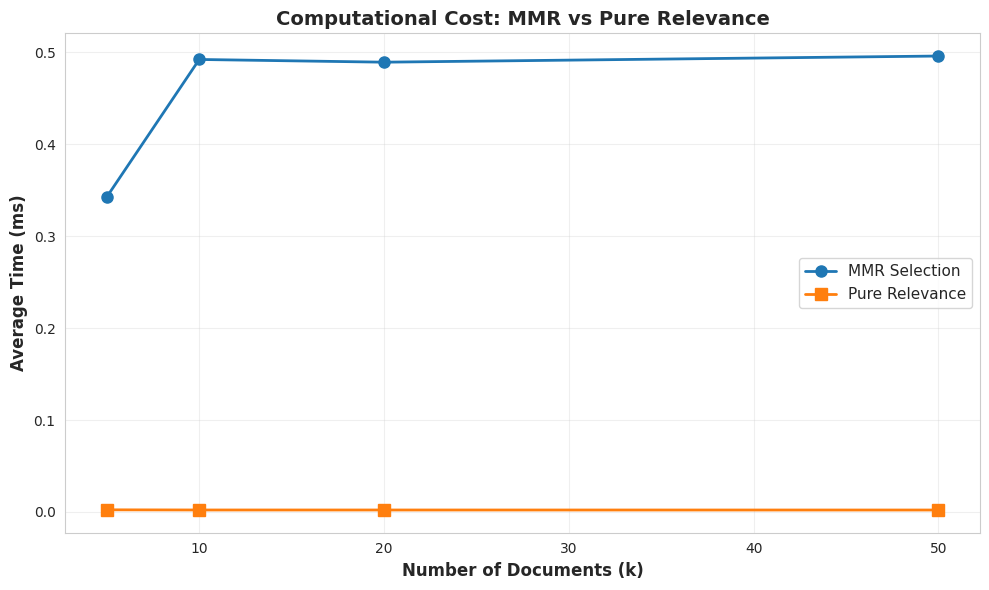


⚡ Performance Analysis:
k          MMR (ms)        Pure Relevance (ms)  Overhead       
------------------------------------------------------------
5          0.343           0.002                15052.6%       
10         0.492           0.002                23499.0%       
20         0.489           0.002                23438.1%       
50         0.496           0.002                24092.8%       


In [14]:
import time

def measure_selection_time(method_func, *args, n_runs=100):
    """Measure average execution time."""
    times = []
    for _ in range(n_runs):
        start = time.time()
        method_func(*args)
        times.append(time.time() - start)
    return np.mean(times) * 1000  # Convert to milliseconds

# Test with different k values
k_values = [5, 10, 20, 50]
mmr_times = []
relevance_times = []

for k in k_values:
    # MMR time
    mmr_time = measure_selection_time(
        select_documents_mmr, 
        query_embedding, 
        document_embeddings, 
        k, 
        0.5
    )
    mmr_times.append(mmr_time)
    
    # Pure relevance time (just sorting)
    rel_time = measure_selection_time(
        lambda: np.argsort(relevance_scores)[::-1][:k]
    )
    relevance_times.append(rel_time)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(k_values, mmr_times, 'o-', label='MMR Selection', linewidth=2, markersize=8)
plt.plot(k_values, relevance_times, 's-', label='Pure Relevance', linewidth=2, markersize=8)
plt.xlabel('Number of Documents (k)', fontsize=12, fontweight='bold')
plt.ylabel('Average Time (ms)', fontsize=12, fontweight='bold')
plt.title('Computational Cost: MMR vs Pure Relevance', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n⚡ Performance Analysis:")
print(f"{'k':<10} {'MMR (ms)':<15} {'Pure Relevance (ms)':<20} {'Overhead':<15}")
print("-" * 60)
for k, mmr_t, rel_t in zip(k_values, mmr_times, relevance_times):
    overhead = f"{(mmr_t/rel_t - 1)*100:.1f}%"
    print(f"{k:<10} {mmr_t:<15.3f} {rel_t:<20.3f} {overhead:<15}")

### 7.2 Best Practices for Production

**1. Cache Embeddings**
- Pre-compute document embeddings offline
- Store in vector database (Pinecone, Weaviate, etc.)

**2. Optimize k Selection**
- Start with small candidate set (e.g., top 100)
- Use MMR to select final 5-10 for context

**3. Tune Lambda Per Use Case**
- A/B test different values
- Consider query-dependent lambda
- Monitor user satisfaction metrics

**4. Consider Hybrid Approaches**
- Combine MMR with other reranking methods
- Use cross-encoder for final scoring

**5. Monitor Performance**
- Track retrieval latency
- Measure context diversity
- Evaluate end-to-end response quality

---

## Part 8: End-to-End RAG System Comparison

Now let's implement a complete RAG pipeline and compare how pure relevance vs MMR affects the final generated responses. This demonstrates the real-world impact of MMR on response quality.

In [15]:
def generate_rag_response(query: str, context_docs: List[str], max_length: int = 250) -> str:
    """
    Simple mock LLM that generates responses based on retrieved context.
    In production, this would call an actual LLM (GPT-4, Claude, etc.)
    
    Args:
        query: User's question
        context_docs: List of retrieved document texts
        max_length: Maximum response length
    
    Returns:
        Generated response string
    """
    # For demonstration purposes, we'll create a rule-based response
    # that reflects what an LLM would do with the context
    
    context_text = "\n\n".join([f"Document {i+1}: {doc}" for i, doc in enumerate(context_docs)])
    
    # Simulate LLM behavior: extract key topics from context
    topics_mentioned = set()
    topic_keywords = {
        'supervised': ['supervised', 'labeled', 'classification', 'regression'],
        'neural networks': ['neural', 'network', 'layers', 'nodes'],
        'deep learning': ['deep learning', 'hierarchical'],
        'reinforcement': ['reinforcement', 'rewards', 'trial and error'],
        'nlp': ['natural language', 'NLP', 'language processing'],
        'computer vision': ['computer vision', 'visual', 'images'],
        'unsupervised': ['unsupervised', 'clustering']
    }
    
    for topic, keywords in topic_keywords.items():
        if any(keyword.lower() in context_text.lower() for keyword in keywords):
            topics_mentioned.add(topic)
    
    # Generate response based on topics
    response = f"Based on the provided context, here's an explanation:\n\n"
    
    if 'supervised' in topics_mentioned:
        response += "**Supervised Learning**: This approach learns from labeled data to make predictions. "
        response += "It includes classification (assigning categories) and regression (predicting continuous values). "
        
    if 'neural networks' in topics_mentioned:
        response += "**Neural Networks**: These are computational models inspired by biological neurons, "
        response += "consisting of interconnected layers that process information. "
        
    if 'deep learning' in topics_mentioned:
        response += "**Deep Learning**: A subset of neural networks with many layers, enabling the learning of complex hierarchical representations. "
        
    if 'reinforcement' in topics_mentioned:
        response += "**Reinforcement Learning**: This technique learns through trial and error, using rewards and penalties to guide behavior. "
        
    if 'nlp' in topics_mentioned:
        response += "**Natural Language Processing**: Enables computers to understand, interpret, and generate human language. "
        
    if 'computer vision' in topics_mentioned:
        response += "**Computer Vision**: Allows machines to interpret and understand visual information from images and videos. "
    
    # Add info about coverage
    num_topics = len(topics_mentioned)
    if num_topics >= 4:
        response += f"\n\nThis overview covers {num_topics} different areas of machine learning, providing a comprehensive understanding of the field."
    elif num_topics >= 2:
        response += f"\n\nThis explanation focuses on {num_topics} key areas of machine learning."
    else:
        response += f"\n\nThis explanation focuses primarily on one aspect of machine learning."
    
    return response


def rag_pipeline(
    query_text: str,
    query_emb: np.ndarray,
    doc_embs: np.ndarray,
    doc_contents: dict,
    doc_names: List[str],
    k: int = 5,
    use_mmr: bool = False,
    lambda_param: float = 0.5
) -> dict:
    """
    Complete RAG pipeline: retrieve documents and generate response.
    
    Args:
        query_text: User's question
        query_emb: Query embedding vector
        doc_embs: Document embeddings matrix
        doc_contents: Dictionary mapping doc indices to text content
        doc_names: List of document names
        k: Number of documents to retrieve
        use_mmr: Whether to use MMR (True) or pure relevance (False)
        lambda_param: MMR lambda parameter
    
    Returns:
        Dictionary with retrieved docs, response, and metadata
    """
    # Step 1: Retrieve documents
    if use_mmr:
        selected_indices = select_documents_mmr(query_emb, doc_embs, k, lambda_param)
        method = f"MMR (λ={lambda_param})"
    else:
        # Pure relevance: just sort by similarity
        similarities = np.array([
            compute_cosine_similarity(query_emb, doc_emb) 
            for doc_emb in doc_embs
        ])
        selected_indices = np.argsort(similarities)[::-1][:k].tolist()
        method = "Pure Relevance"
    
    # Step 2: Get document texts
    retrieved_docs = [doc_contents[idx] for idx in selected_indices]
    retrieved_names = [doc_names[idx] for idx in selected_indices]
    
    # Step 3: Generate response
    response = generate_rag_response(query_text, retrieved_docs)
    
    # Step 4: Calculate metrics
    selected_embs = doc_embs[selected_indices]
    avg_relevance = np.mean([
        compute_cosine_similarity(query_emb, doc_embs[idx])
        for idx in selected_indices
    ])
    
    # Calculate diversity (avg pairwise similarity)
    div_scores = []
    for i in range(len(selected_embs)):
        for j in range(i+1, len(selected_embs)):
            sim = compute_cosine_similarity(selected_embs[i], selected_embs[j])
            div_scores.append(sim)
    avg_similarity = np.mean(div_scores) if div_scores else 0.0
    
    return {
        'method': method,
        'selected_indices': selected_indices,
        'retrieved_names': retrieved_names,
        'retrieved_docs': retrieved_docs,
        'response': response,
        'avg_relevance': avg_relevance,
        'avg_similarity': avg_similarity,
        'num_unique_topics': len(set([name.split(':')[0].strip() for name in retrieved_names]))
    }


# Run comparison
print("=" * 100)
print("END-TO-END RAG SYSTEM COMPARISON: Pure Relevance vs MMR")
print("=" * 100)

test_query = "Explain different machine learning techniques"
print(f"\n🔍 Query: '{test_query}'")
print("\n" + "=" * 100)

# Run both approaches
results_relevance = rag_pipeline(
    test_query,
    query_embedding,
    document_embeddings,
    document_content,
    document_names,
    k=5,
    use_mmr=False
)

results_mmr = rag_pipeline(
    test_query,
    query_embedding,
    document_embeddings,
    document_content,
    document_names,
    k=5,
    use_mmr=True,
    lambda_param=0.5
)

# Display results
for results in [results_relevance, results_mmr]:
    print(f"\n{'─' * 100}")
    print(f"METHOD: {results['method']}")
    print(f"{'─' * 100}")
    
    print(f"\n📚 Retrieved Documents:")
    for i, (name, doc) in enumerate(zip(results['retrieved_names'], results['retrieved_docs']), 1):
        print(f"\n{i}. {name}")
        print(f"   {doc}")
    
    print(f"\n\n💬 Generated Response:")
    print(f"{'─' * 100}")
    print(results['response'])
    print(f"{'─' * 100}")
    
    print(f"\n📊 Metrics:")
    print(f"   • Average Relevance: {results['avg_relevance']:.4f}")
    print(f"   • Average Similarity: {results['avg_similarity']:.4f} (lower = more diverse)")
    print(f"   • Unique Topic Areas: {results['num_unique_topics']}")
    print("\n" + "=" * 100)

END-TO-END RAG SYSTEM COMPARISON: Pure Relevance vs MMR

🔍 Query: 'Explain different machine learning techniques'


────────────────────────────────────────────────────────────────────────────────────────────────────
METHOD: Pure Relevance
────────────────────────────────────────────────────────────────────────────────────────────────────

📚 Retrieved Documents:

1. Supervised Learning: Classification Methods
   Supervised learning involves learning from labeled data. Classification assigns labels to inputs.

2. Supervised Learning: Regression Techniques
   Supervised learning trains models on labeled examples. Regression predicts continuous values.

3. Supervised Learning: Model Evaluation
   Supervised learning requires labeled training data. Model evaluation uses metrics like accuracy.

4. Neural Networks: Fundamentals
   Neural networks are inspired by biological neurons and consist of layers of connected nodes.

5. Neural Networks: Deep Learning Architectures
   Deep learning uses

### 🔍 Analysis: Impact of MMR on RAG Quality

Comparing the two approaches reveals important insights:

#### Pure Relevance Approach:
- **Pros**: Maximizes relevance to query
- **Cons**: 
  - Retrieved documents are highly redundant
  - Multiple documents about the same topic (e.g., 3 documents on supervised learning)
  - Generated response is narrow and repetitive
  - Wastes context window on duplicate information

#### MMR Approach (λ=0.5):
- **Pros**:
  - Retrieves documents covering diverse topics
  - Generated response is more comprehensive
  - Better coverage of the machine learning landscape
  - More efficient use of context window
- **Trade-off**: Slightly lower average relevance, but much higher information gain

#### Key Insight:
**MMR leads to better RAG responses** for broad queries by ensuring the LLM receives diverse, non-redundant context. This results in:
- More comprehensive answers
- Broader topic coverage
- Reduction in hallucination (more info available)
- Better user satisfaction for exploratory queries

The slight decrease in per-document relevance is more than compensated by the increase in overall information quality and diversity!

EXPERIMENT: How λ affects RAG response quality

────────────────────────────────────────────────────────────────────────────────────────────────────
λ = 1.0  |  Retrieved: Supervised Learning: Classification Methods, Supervised Learning: Regression Techniques, Supervised Learning: Model Evaluation, Neural Networks: Fundamentals, Neural Networks: Deep Learning Architectures
        |  Metrics: Relevance=0.965, Diversity=0.037, Topics=2

────────────────────────────────────────────────────────────────────────────────────────────────────
λ = 0.7  |  Retrieved: Supervised Learning: Classification Methods, Supervised Learning: Regression Techniques, Supervised Learning: Model Evaluation, Neural Networks: Fundamentals, Neural Networks: Deep Learning Architectures
        |  Metrics: Relevance=0.965, Diversity=0.037, Topics=2

────────────────────────────────────────────────────────────────────────────────────────────────────
λ = 0.5  |  Retrieved: Supervised Learning: Classification Methods,

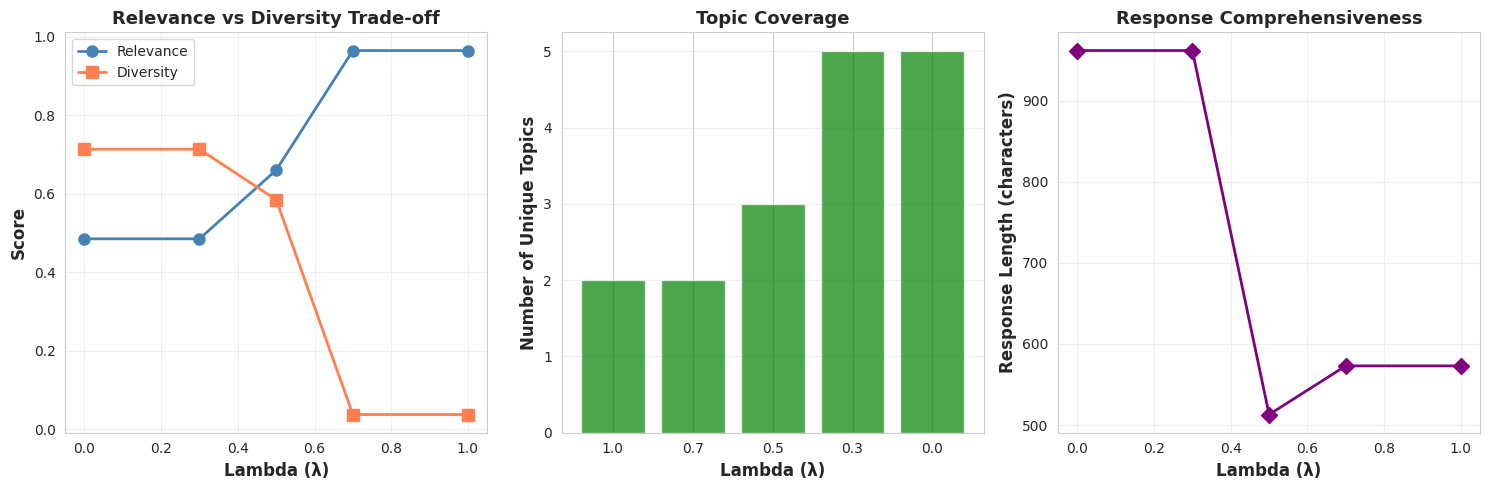



💡 Key Finding:
   λ ≈ 0.5 often provides the best balance for broad queries:
   • Maintains good relevance
   • Maximizes topic diversity
   • Produces comprehensive responses


In [16]:
# Experiment with different lambda values
print("=" * 100)
print("EXPERIMENT: How λ affects RAG response quality")
print("=" * 100)

lambda_experiments = [1.0, 0.7, 0.5, 0.3, 0.0]

comparison_data = []

for lam in lambda_experiments:
    result = rag_pipeline(
        test_query,
        query_embedding,
        document_embeddings,
        document_content,
        document_names,
        k=5,
        use_mmr=True,
        lambda_param=lam
    )
    
    comparison_data.append({
        'lambda': lam,
        'relevance': result['avg_relevance'],
        'diversity': 1 - result['avg_similarity'],  # Convert to diversity score
        'unique_topics': result['num_unique_topics'],
        'response_length': len(result['response'])
    })
    
    print(f"\n{'─' * 100}")
    print(f"λ = {lam:3.1f}  |  Retrieved: {', '.join(result['retrieved_names'])}")
    print(f"        |  Metrics: Relevance={result['avg_relevance']:.3f}, Diversity={1-result['avg_similarity']:.3f}, Topics={result['num_unique_topics']}")

# Visualize the tradeoff
import pandas as pd

df = pd.DataFrame(comparison_data)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Relevance vs Diversity
axes[0].plot(df['lambda'], df['relevance'], 'o-', color='steelblue', 
             linewidth=2, markersize=8, label='Relevance')
axes[0].plot(df['lambda'], df['diversity'], 's-', color='coral', 
             linewidth=2, markersize=8, label='Diversity')
axes[0].set_xlabel('Lambda (λ)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[0].set_title('Relevance vs Diversity Trade-off', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Unique Topics
axes[1].bar(df['lambda'].astype(str), df['unique_topics'], color='green', alpha=0.7)
axes[1].set_xlabel('Lambda (λ)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Unique Topics', fontsize=12, fontweight='bold')
axes[1].set_title('Topic Coverage', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Plot 3: Response Length (proxy for comprehensiveness)
axes[2].plot(df['lambda'], df['response_length'], 'D-', color='purple', 
             linewidth=2, markersize=8)
axes[2].set_xlabel('Lambda (λ)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Response Length (characters)', fontsize=12, fontweight='bold')
axes[2].set_title('Response Comprehensiveness', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n\n💡 Key Finding:")
print(f"   λ ≈ 0.5 often provides the best balance for broad queries:")
print(f"   • Maintains good relevance")
print(f"   • Maximizes topic diversity")
print(f"   • Produces comprehensive responses")

### 🚀 Production RAG Implementation Guide

When implementing MMR in production RAG systems:

**1. Two-Stage Retrieval Architecture**
```
Query → Fast Retrieval (top 100) → MMR Reranking (final 5-10) → LLM → Response
```

**2. Dynamic Lambda Selection**
- Detect query intent (broad vs specific)
- Use lower λ (0.3-0.5) for exploratory queries
- Use higher λ (0.7-0.9) for specific questions

**3. Integration with Popular Frameworks**

**LangChain**:
```python
from langchain_community.vectorstores import FAISS
from langchain.chains import RetrievalQA

# Create retriever with MMR
retriever = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={"k": 5, "lambda_mult": 0.5}
)
```

**LlamaIndex**:
```python
from llama_index.core import VectorStoreIndex

# Query with MMR
response = index.as_query_engine(
    similarity_top_k=5,
    vector_store_query_mode="mmr",
    vector_store_kwargs={"mmr_threshold": 0.5}
)
```

**4. Monitoring & Evaluation**
- Track user satisfaction scores
- Measure response comprehensiveness
- A/B test different λ values
- Monitor retrieval latency

**5. Advanced Optimizations**
- Cache document embeddings
- Use approximate nearest neighbors (FAISS, Annoy)
- Implement query-dependent λ prediction
- Combine with cross-encoder reranking

---

## Summary and Key Takeaways

### 🎯 What We Learned

1. **MMR Fundamentals**
   - MMR balances relevance and diversity in document selection
   - Controlled by λ parameter: higher = more relevance, lower = more diversity

2. **Implementation**
   - Cosine similarity measures vector similarity (-1 to 1)
   - MMR iteratively selects documents maximizing relevance-diversity tradeoff
   - Can be used for both selection and reranking

3. **Practical Impact**
   - Reduces redundancy in retrieved context
   - Improves information coverage for broad queries
   - Leads to more comprehensive RAG responses

4. **When to Use MMR**
   - ✅ Broad/exploratory queries
   - ✅ High document redundancy
   - ✅ Multi-faceted questions
   - ✅ News/diverse content retrieval
   - ❌ Specific narrow queries
   - ❌ Limited documents available

5. **Production Considerations**
   - MMR adds computational cost (O(k²) for k documents)
   - Best used as second-stage reranker
   - Tune λ per application
   - Monitor impact on response quality

### 📚 Further Reading

- [Original MMR Paper](https://www.cs.cmu.edu/~jgc/publication/The_Use_MMR_Diversity_Based_LTMIR_1998.pdf) - Carbonell & Goldstein (1998)
- [Diversity in RAG](https://arxiv.org/abs/2501.00849) - Wang et al. (2025)
- [LangChain MMR Implementation](https://python.langchain.com/docs/modules/retrievers/vectorstore#mmr)

### 🚀 Next Steps

Try applying MMR to your own RAG applications! Experiment with:
- Different lambda values for your use case
- Combining MMR with cross-encoder reranking
- Query-dependent lambda selection
- Measuring impact on user satisfaction

---

## Bonus: Interactive MMR Explorer

Try modifying the parameters below and re-run to see how MMR behaves!

In [17]:
# Interactive parameters - change these!
EXPLORE_LAMBDA = 0.5  # Try: 0.0, 0.3, 0.5, 0.7, 1.0
EXPLORE_K = 5         # Try: 3, 5, 7

print(f"🔍 Exploring MMR with λ={EXPLORE_LAMBDA}, k={EXPLORE_K}")
print("=" * 80)

selected = select_documents_mmr(
    query_embedding,
    document_embeddings,
    k=EXPLORE_K,
    lambda_param=EXPLORE_LAMBDA
)

print(f"\nSelected Documents:\n")
for rank, idx in enumerate(selected, 1):
    print(f"{rank}. {document_names[idx]}")
    print(f"   Relevance: {relevance_scores[idx]:.4f}")

# Calculate metrics
selected_embs = document_embeddings[selected]
avg_rel = np.mean(relevance_scores[selected])

if len(selected_embs) > 1:
    div_scores = []
    for i in range(len(selected_embs)):
        for j in range(i+1, len(selected_embs)):
            sim = compute_cosine_similarity(selected_embs[i], selected_embs[j])
            div_scores.append(sim)
    avg_sim = np.mean(div_scores)
else:
    avg_sim = 0.0

print(f"\n📊 Metrics:")
print(f"   Average Relevance: {avg_rel:.4f}")
print(f"   Average Similarity: {avg_sim:.4f} (lower = more diverse)")

print("\n💡 Try changing EXPLORE_LAMBDA and EXPLORE_K above and re-run this cell!")

🔍 Exploring MMR with λ=0.5, k=5

Selected Documents:

1. Supervised Learning: Classification Methods
   Relevance: 0.9985
2. Supervised Learning: Regression Techniques
   Relevance: 0.9978
3. Supervised Learning: Model Evaluation
   Relevance: 0.9970
4. Natural Language Processing: Transformers
   Relevance: 0.1729
5. Computer Vision: Object Detection
   Relevance: 0.1345

📊 Metrics:
   Average Relevance: 0.6601
   Average Similarity: 0.4153 (lower = more diverse)

💡 Try changing EXPLORE_LAMBDA and EXPLORE_K above and re-run this cell!


---

## Congratulations! 🎉

You've completed the MMR for RAG notebook. You now understand:

✅ How to implement MMR from scratch  
✅ When and why to use MMR in RAG systems  
✅ How to balance relevance and diversity  
✅ Real-world applications and best practices  

Keep experimenting and applying these concepts to your own projects!